# Machine Learning Lab – Exercise 2

## Body Weight Prediction using Multiple Linear Regression

### Objective
To build a Multiple Linear Regression model to predict body weight using height and gender.

### Algorithm Used
Multiple Linear Regression

### Problem Type
Supervised Learning – Regression

### Input Features
- Height
- Gender

### Target Variable
Body Weight

### Steps
1. Load the required libraries.
2. Load or create the dataset containing height, gender, and body weight.
3. Explore the dataset.
4. Check for missing values.
5. Encode the gender variable.
6. Select height and gender as input features.
7. Select body weight as the target variable.
8. Split the data into training and testing sets.
9. Train the Multiple Linear Regression model.
10. Predict body weight for the test data.
11. Evaluate the model using suitable regression metrics.
12. Visualize the actual and predicted body weights.
13. Summarize the results.

## Dataset

### Dataset Name
Height, Gender and Body Weight Dataset

### Dataset Description
The dataset contains observations of individuals with their height, gender, and corresponding body weight.

### Input Features
- Height
- Gender

### Target Variable
Body Weight

### Data Preparation
The gender variable will be encoded into numerical form before training the Multiple Linear Regression model.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create the Height, Gender and Body Weight dataset

data = {
    "Height": [150, 152, 155, 158, 160, 162, 165, 168, 170, 172,
               175, 178, 180, 183, 185, 188, 190, 192, 195, 198],
    "Gender": ["Female", "Female", "Female", "Female", "Female",
               "Female", "Female", "Female", "Female", "Female",
               "Male", "Male", "Male", "Male", "Male",
               "Male", "Male", "Male", "Male", "Male"],
    "Weight": [50, 52, 54, 56, 58, 60, 62, 64, 66, 68,
               70, 73, 76, 79, 82, 85, 88, 91, 94, 97]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset created successfully!
Shape of dataset: (20, 3)


,Height,Gender,Weight
0,150,Female,50
1,152,Female,52
2,155,Female,54
3,158,Female,56
4,160,Female,58


In [3]:
# Explore the dataset

print("Dataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Height  20 non-null     int64 
 1   Gender  20 non-null     object
 2   Weight  20 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 612.0+ bytes
None

Statistical Summary:
           Height     Weight
count   20.000000  20.000000
mean   173.800000  71.250000
std     14.869963  14.642674
min    150.000000  50.000000
25%    161.500000  59.500000
50%    173.500000  69.000000
75%    185.750000  82.750000
max    198.000000  97.000000


In [4]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Height    0
Gender    0
Weight    0
dtype: int64


In [5]:
# Encode the Gender variable

df["Gender_Encoded"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

print("Gender encoding completed successfully!")
print(df[["Gender", "Gender_Encoded"]].head(10))

Gender encoding completed successfully!
   Gender  Gender_Encoded
0  Female               0
1  Female               0
2  Female               0
3  Female               0
4  Female               0
5  Female               0
6  Female               0
7  Female               0
8  Female               0
9  Female               0


In [6]:
# Separate input features and target variable

X = df[["Height", "Gender_Encoded"]]
y = df["Weight"]

print("Input features (X):")
print(X.head())

print("\nTarget variable (y):")
print(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features (X):
   Height  Gender_Encoded
0     150               0
1     152               0
2     155               0
3     158               0
4     160               0

Target variable (y):
0    50
1    52
2    54
3    56
4    58
Name: Weight, dtype: int64

X shape: (20, 2)
y shape: (20,)


In [7]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data shape:
X_train: (16, 2)
y_train: (16,)

Testing data shape:
X_test: (4, 2)
y_test: (4,)


In [8]:
# Train the Multiple Linear Regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully!")

Multiple Linear Regression model trained successfully!


In [9]:
# Display the Multiple Linear Regression equation

print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

print("\nMultiple Linear Regression Equation:")
print(
    f"Weight = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} × Height) "
    f"+ ({model.coef_[1]:.4f} × Gender_Encoded)"
)

Intercept: -112.93486523842432

Coefficients:
Height : 1.0621976503109882
Gender_Encoded : -1.7277988942639944

Multiple Linear Regression Equation:
Weight = -112.9349 + (1.0622 × Height) + (-1.7278 × Gender_Encoded)


In [10]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nActual body weights:")
print(y_test.values)

print("\nPredicted body weights:")
print(y_pred)

Predictions generated successfully!

Actual body weights:
[50 91 85 52]

Predicted body weights:
[46.39478231 89.27928473 85.03049413 48.51917761]


In [11]:
# Evaluate the Multiple Linear Regression model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 2.209312370421557
Mean Squared Error (MSE): 7.018877516555936
Root Mean Squared Error (RMSE): 2.6493164243925142
R² Score: 0.9797872497723371


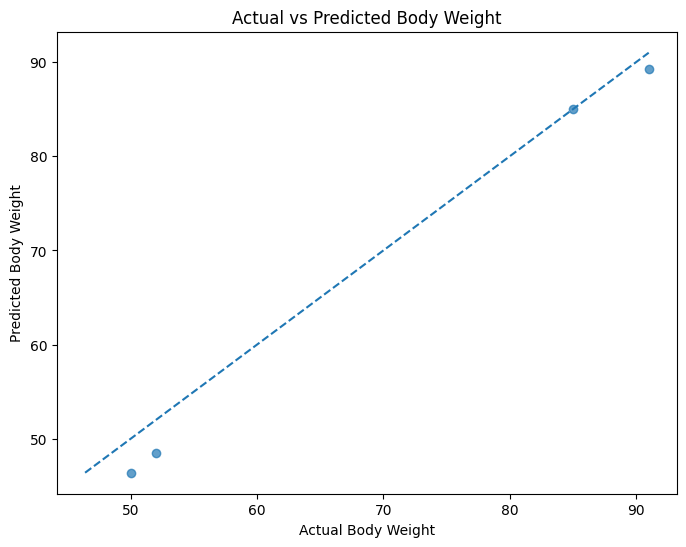

In [12]:
# Visualize actual vs predicted body weights

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Reference line for perfect predictions
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Body Weight")
plt.ylabel("Predicted Body Weight")
plt.title("Actual vs Predicted Body Weight")

plt.show()

In [13]:
# Create a summary of model performance

results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

results

,Metric,Value
0,MAE,2.209312
1,MSE,7.018878
2,RMSE,2.649316
3,R² Score,0.979787


## Result

The Multiple Linear Regression model was successfully trained to predict body weight using height and gender.

The gender variable was encoded numerically, with Female represented as 0 and Male represented as 1.

### Model Performance

- Mean Absolute Error (MAE): 2.209313
- Mean Squared Error (MSE): 7.018878
- Root Mean Squared Error (RMSE): 2.649316
- R² Score: 0.979787

The model achieved an R² score of approximately 0.980 on the test dataset.

## Conclusion

The Multiple Linear Regression model successfully predicted body weight using height and gender as input features. The Actual vs Predicted Body Weight plot shows that the predicted values are relatively close to the actual values for the test observations.

Since the test set contains only four observations, the evaluation metrics should be interpreted with caution.